In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

base = Path.cwd()
root = base if (base / "data").exists() else base.parent

df = pd.read_csv(root / "data" / "processed" / "model_features.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

feature_cols = [c for c in df.columns if c.startswith(("Home_", "Away_")) or c.endswith("_form_diff")]

train = df[df["Season"] != "2025-26"]
test = df[df["Season"] == "2025-26"]

X_train, y_train = train[feature_cols], train["Target"]
X_test, y_test = test[feature_cols], test["Target"]

print("Train matches:", len(train), "| Test matches:", len(test))
print("Features used:", len(feature_cols))

Train matches: 1472 | Test matches: 377
Features used: 12


In [2]:
names = {0: "Home Win", 1: "Draw", 2: "Away Win"}

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline accuracy: {base_acc:.3f}")

Baseline accuracy: 0.422


In [3]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
lr_pred = logreg.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Regression accuracy: {lr_acc:.3f}")

Logistic Regression accuracy: 0.446


In [4]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest accuracy: {rf_acc:.3f}")

Random Forest accuracy: 0.467


In [5]:
print("Random Forest, per-class report")
print(classification_report(y_test, rf_pred, target_names=["Home Win", "Draw", "Away Win"], zero_division=0))

Random Forest, per-class report
              precision    recall  f1-score   support

    Home Win       0.48      0.79      0.59       159
        Draw       0.00      0.00      0.00       104
    Away Win       0.45      0.44      0.44       114

    accuracy                           0.47       377
   macro avg       0.31      0.41      0.35       377
weighted avg       0.34      0.47      0.39       377



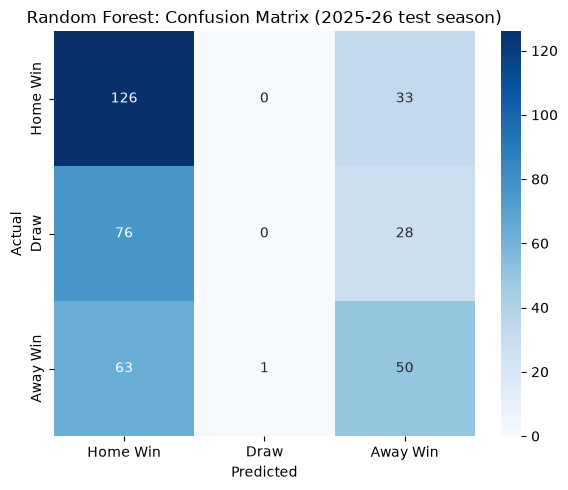

In [6]:
labels = ["Home Win", "Draw", "Away Win"]
cm = confusion_matrix(y_test, rf_pred)

fig_dir = root / "images"
fig_dir.mkdir(exist_ok=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Random Forest: Confusion Matrix (2025-26 test season)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(fig_dir / "07_confusion_matrix.png", dpi=150)
plt.show()

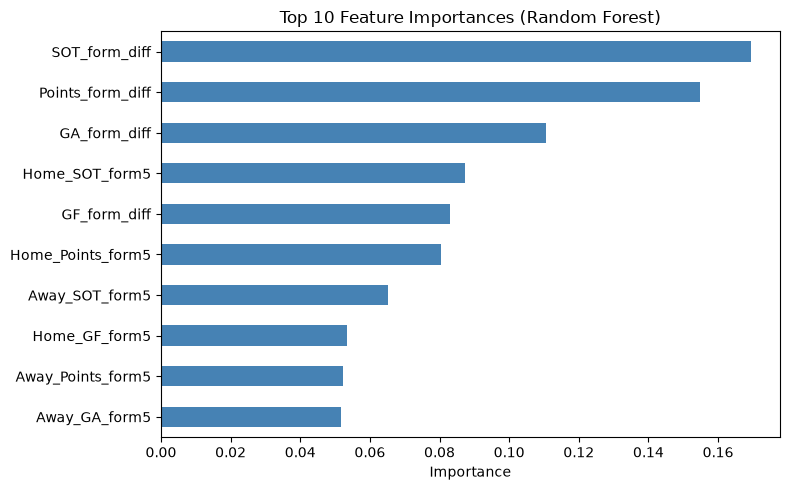

In [7]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values().tail(10)

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(fig_dir / "08_feature_importance.png", dpi=150)
plt.show()